In [1]:
from pathlib import Path

import numpy as np
import tensorflow as tf

from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score

from data.generators import HAMDataGenerator
from data.preprocessing import HAMDataProcessor
from ham_clf.utils.loggers import HAMLogger

In [2]:
ROOT = Path.cwd().parent.parent
filepath = ROOT / "images" / "HAM10000_metadata.csv"
logconf_path = ROOT / "conf" / "logconf.yaml"

logger = HAMLogger()
log = logger.configure_from_file(logconf_path)
data_processor = HAMDataProcessor(filepath, log=log)
train_df, _, test_df = data_processor.preprocess()
data_generator = HAMDataGenerator(train_df)
test_ds = data_generator.flow_from_dataframe(
    test_df, filepath.with_name("HAM10000_images_full"), x_col="image_id", y_col="dx"
)

In [5]:
for images_batch, labels_batch in test_ds.take(3).as_numpy_iterator():
    log.info(f"{images_batch.shape}, {labels_batch.argmax(axis=1)}")

[INFO]:
(16, 224, 224, 3), [5 5 4 3 4 5 4 4 2 2 1 4 2 2 2 4]
[INFO]:
(16, 224, 224, 3), [5 4 4 4 4 2 4 1 4 4 2 4 4 4 2 4]
[INFO]:
(16, 224, 224, 3), [4 4 2 0 5 4 4 4 2 4 4 4 4 4 2 2]


In [6]:
mobilenet_ft = tf.keras.models.load_model("mobilenetv2_ft0.keras")

predictions_one_hot = mobilenet_ft.predict(test_ds.map(lambda x, _: x))
y_pred = predictions_one_hot.argmax(axis=1)
y_true_one_hot = np.concatenate(list(test_ds.map(lambda _, y: y)))
y_true = y_true_one_hot.argmax(axis=1)

assert len(y_true) == len(y_pred)

71/71 ━━━━━━━━━━━━━━━━━━━━ 13s 173ms/step


[INFO]:
accuracy_score: 78.947%


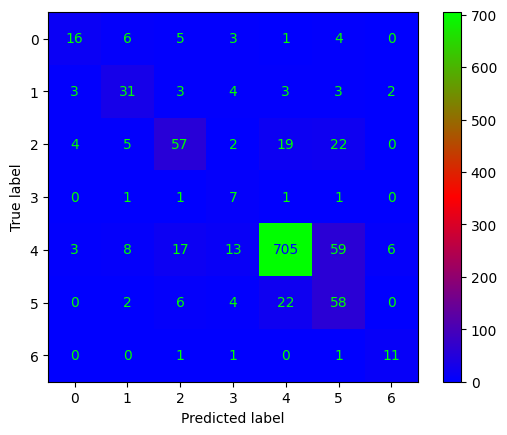

In [7]:
log.info(f"accuracy_score: {accuracy_score(y_true, y_pred):.3%}")
ConfusionMatrixDisplay.from_predictions(y_true, y_pred, cmap="brg");